In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd

import numpy as np
import json
import os

In [2]:
dataset_path_intercity = '../dataset/traffic/intercity'
dataset_path_urban = '../dataset/traffic/urban'

In [3]:
def read_and_concat_excels(folder_path, extensions=('.xlsx', '.xls'), ignore_index=True):
    all_dfs = []

    for filename in os.listdir(folder_path):
        if filename.endswith(extensions):
            file_path = os.path.join(folder_path, filename)
            try:
                df = pd.read_excel(file_path)
                df['source_file'] = filename  # 🔍 어떤 파일에서 왔는지 추적
                all_dfs.append(df)
            except Exception as e:
                print(f"❌ 파일 '{filename}' 읽기 실패: {e}")

    # ✅ 병합 (row 방향으로 concat)
    if all_dfs:
        merged_df = pd.concat(all_dfs, ignore_index=ignore_index)
        return merged_df
    else:
        print("⚠️ 읽을 수 있는 엑셀 파일이 없습니다.")
        return pd.DataFrame()


In [4]:

intercity_df = read_and_concat_excels(dataset_path_intercity)
urban_df = read_and_concat_excels(dataset_path_urban)




In [5]:
urban_df.columns

Index(['일자', '시도(출발)', '시군구(출발)', '읍면동(출발)', '시도(도착)', '시군구(도착)', '읍면동(도착)',
       '통행량', '통행시간', '통행거리', 'source_file'],
      dtype='object')

In [6]:
intercity_df['행정구역'] = intercity_df['시도(도착)'].astype(str).str.strip() + " " + intercity_df['시군구(도착)'].astype(str).str.strip()
urban_df['행정구역'] = urban_df['시도(도착)'].astype(str).str.strip() + " " + urban_df['시군구(도착)'].astype(str).str.strip()



In [7]:

intercity_col_list=  ['행정구역','철도(통행량)', '고속버스(통행량)', '시외버스(통행량)']
urban_col_list = ['행정구역', '통행량']

intercity_df = intercity_df[intercity_col_list]
urban_df = urban_df[urban_col_list]

In [8]:
concat_df = pd.merge(left=intercity_df, right=urban_df, how = "outer", on = "행정구역" )

In [9]:
concat_df = concat_df.fillna(0)

concat_df['총통행량'] = concat_df[['철도(통행량)', '고속버스(통행량)', '시외버스(통행량)', '통행량']].fillna(0).sum(axis=1)
concat_df = concat_df.sort_values(by='총통행량', ascending=False).reset_index(drop=True)

In [10]:
concat_df.to_csv('./ref_dataset/traffic.csv', encoding='cp949')

In [11]:
concat_df = concat_df.iloc[:10]

In [12]:
import plotly.graph_objects as go
# x축: 행정구역
x = concat_df['행정구역']

# 시각화 시작
fig = go.Figure()

# 막대그래프: 총통행량
fig.add_trace(go.Bar(
    x=x,
    y=concat_df['총통행량'],
    name='총통행량',
    yaxis='y1'
))

# 라인그래프: 개별 교통수단
for col in ['철도(통행량)', '고속버스(통행량)', '시외버스(통행량)', '통행량']:
    fig.add_trace(go.Scatter(
        x=x,
        y=concat_df[col],
        name=col.replace('(통행량)', ''),
        mode='lines+markers',
        yaxis='y2'
    ))

# 레이아웃 설정
fig.update_layout(
    title='행정구역별 총통행량 및 교통수단별 통행량',
    xaxis=dict(title='행정구역'),
    yaxis=dict(
        title='총통행량 (막대)',
        side='left',
        showgrid=False
    ),
    yaxis2=dict(
        title='교통수단별 통행량 (라인)',
        overlaying='y',
        side='right',
        showgrid=False
    ),
    width=1100,
    height=600
)

fig.show()


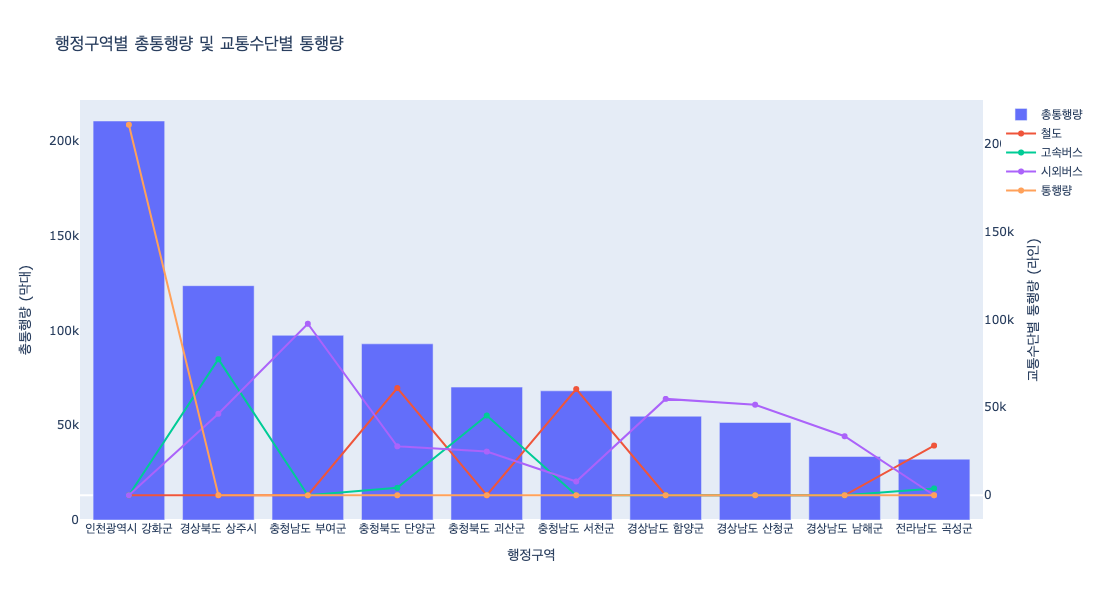

In [13]:
import plotly.io as pio
pio.show(fig, renderer="png")

In [14]:
fig.write_html('./plot/traffic.html')